In [2]:
%reset -f
import pandas as pd
import numpy as np
import pickle
from patsy import dmatrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

- **Load the data**

- **Extract the model results**

- **Create NN training dataframe**

In [ ]:
# Copy the training sample
x_train_nn = x_train_spline.copy()

# Store the prior surface, the prior total variance, and the actual total variance
x_train_nn['iv_prior'] = iv_pred_train_spline
x_train_nn['w_prior'] = x_train_nn['iv_prior'] ** 2 * x_train_nn['T']
x_train_nn['w_actual'] = x_train_nn['iv_fun'] **2 * x_train_nn['T']

- **Neural network architecture**

- **Prepare the data**

- **Train the actual neural network**

In [141]:

import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

# ============================================================
# Load spline results
# ============================================================

with open("/Users/euanbronsky/PyCharmMiscProject/spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)

# ============================================================
# Extract spline objects
# ============================================================

at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]

x_train_spline = res_spline["x_train_spline"]
data_spline_full = res_spline["data_spline_full"]


# ============================================================
# Functions needed to reconstruct spline predictions
# ============================================================

def prepare_groups_spline(x):
    dates = np.sort(x["quote_date"].unique())

    y_groups = []
    Z_groups = []

    for date in dates:
        group = x[x["quote_date"] == date]

        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    return dates, y_groups, Z_groups


def predict_iv(Z_groups, at_pred):
    log_iv_pred = []

    for t in range(len(Z_groups)):
        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    return log_iv_pred, iv_pred


# ============================================================
# Reconstruct training dates from spline model
# ============================================================

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(
    x_train_spline
)

n_train_dates_spline = len(dates_train_spline)

# ============================================================
# Use full non-bucketed data, but only training dates
# ============================================================

x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()

# ============================================================
# Compute spline prior on full training data
# ============================================================

dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn
)

log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)]
)

# ============================================================
# Create NN dataframe
# ============================================================

x_train_nn = x_train_spline_full_nn.copy()

x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn
x_train_nn["w_prior"] = x_train_nn["iv_prior"] ** 2 * x_train_nn["T"]
x_train_nn["w_actual"] = x_train_nn["iv_fun"] ** 2 * x_train_nn["T"]

# This is the correction factor the NN learns
x_train_nn["target_ratio"] = x_train_nn["w_actual"] / x_train_nn["w_prior"]

# ============================================================
# Keep only DOTM_put region
# ============================================================

x_train_nn = x_train_nn[
    x_train_nn["moneyness_group"].eq("DOTM_put")
].copy()

# ============================================================
# Clean training data
# ============================================================

x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)

x_train_nn = x_train_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "w_prior",
        "w_actual",
        "target_ratio"
    ]
)

x_train_nn = x_train_nn[
    x_train_nn["target_ratio"].between(0.25, 4.0)
].copy()

print("Number of DOTM_put training observations:", len(x_train_nn))
print("Average target ratio:", x_train_nn["target_ratio"].mean())


# ============================================================
# Define neural network
# ============================================================

class CorrectionNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(3, 40),
            nn.Tanh(),

            nn.Linear(40, 40),
            nn.Tanh(),

            nn.Linear(40, 40),
            nn.Tanh(),

            nn.Linear(40, 40),
            nn.Tanh()
        )

        self.output = nn.Linear(40, 1)

        self.initialize_weights()

    def initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Linear):
                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                std = (fan_in + fan_out) ** (-0.5)

                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

    def forward(self, x):

        x = self.hidden(x)
        x = self.output(x)

        # Positive correction factor
        return torch.nn.functional.softplus(x) + 1e-4


# ============================================================
# Prepare NN training data
# ============================================================

X = x_train_nn[["M", "T", "iv_prior"]].to_numpy(dtype=float)
y = x_train_nn[["target_ratio"]].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(
    X_tensor,
    y_tensor
)

loader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=True
)

# ============================================================
# Train neural network
# ============================================================

model = CorrectionNN()

initial_lr = 0.001
current_lr = initial_lr

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-5
)

max_epochs = 4000
lr_check_window = 500
stop_check_window = 2000
required_improvement = 0.01

loss_history = []

for epoch in range(max_epochs):

    total_loss = 0.0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        ratio_pred = model(X_batch)

        loss = torch.mean((y_batch - ratio_pred) ** 2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    if epoch > 0 and epoch % lr_check_window == 0:

        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:

            current_lr = current_lr / 2

            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    if epoch > 0 and epoch % stop_check_window == 0:

        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:
            print("Stopping: loss did not improve enough over 2000 epochs")
            break

# ============================================================
# Store fitted correction on DOTM_put training data
# ============================================================

model.eval()

with torch.no_grad():
    ratio_pred_train = model(X_tensor).numpy().flatten()

x_train_nn["nn_ratio"] = ratio_pred_train
x_train_nn["w_nn"] = x_train_nn["nn_ratio"] * x_train_nn["w_prior"]
x_train_nn["iv_nn"] = np.sqrt(x_train_nn["w_nn"] / x_train_nn["T"])

x_train_nn["abs_error_prior"] = (x_train_nn["iv_fun"] - x_train_nn["iv_prior"]).abs()
x_train_nn["abs_error_nn"] = (x_train_nn["iv_fun"] - x_train_nn["iv_nn"]).abs()

print("Spline prior MAE on DOTM_put:", x_train_nn["abs_error_prior"].mean())
print("NN corrected MAE on DOTM_put:", x_train_nn["abs_error_nn"].mean())

# ============================================================
# Save model, scaler, and training dataframe
# ============================================================

nn_dotm_put_results = {
    "model": model,
    "scaler": scaler,
    "x_train_nn": x_train_nn,
    "loss_history": loss_history,
    "features": ["M", "T", "iv_prior"],
    "target": "target_ratio"
}


Number of DOTM_put training observations: 693802
Average target ratio: 1.282109771627842
0 0.04943769097130383 lr: 0.001
50 0.019928650398928244 lr: 0.001
100 0.019780595782748628 lr: 0.001
150 0.019700295088543478 lr: 0.001
200 0.019658805579936083 lr: 0.001
250 0.019638033245846762 lr: 0.001
300 0.01964646283740447 lr: 0.001
350 0.019623947313335617 lr: 0.001
400 0.019606613272465875 lr: 0.001
450 0.019612900355067048 lr: 0.001
500 0.01960965122747342 lr: 0.001
550 0.019593555407439272 lr: 0.001
600 0.019596087140550392 lr: 0.001
650 0.019587775222561526 lr: 0.001
700 0.019586487961685762 lr: 0.001
750 0.019580361658602864 lr: 0.001
800 0.01957023023163411 lr: 0.001
850 0.019584370972066677 lr: 0.001
900 0.019575773319366847 lr: 0.001
950 0.019583825626380325 lr: 0.001
1000 0.019578672696872006 lr: 0.001
Reduced learning rate to 0.0005 at epoch 1000
1050 0.019506197293621425 lr: 0.0005
1100 0.019517545401500566 lr: 0.0005
1150 0.019519320904801993 lr: 0.0005
1200 0.01952134761519752 

In [89]:
import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


# ============================================================
# Load spline results
# ============================================================

with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)


# ============================================================
# Extract spline objects
# ============================================================

at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]

x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]
data_spline_full = res_spline["data_spline_full"]


# ============================================================
# Functions needed to reconstruct spline predictions
# ============================================================

def prepare_groups_spline(x):

    dates = np.sort(x["quote_date"].unique())

    y_groups = []
    Z_groups = []

    for date in dates:

        group = x[x["quote_date"] == date]

        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    return dates, y_groups, Z_groups


def predict_iv(Z_groups, at_pred):

    log_iv_pred = []

    for t in range(len(Z_groups)):

        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    return log_iv_pred, iv_pred


# ============================================================
# Reconstruct training and testing dates from spline model
# ============================================================

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(
    x_train_spline
)

dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(
    x_test_spline
)

n_train_dates_spline = len(dates_train_spline)


# ============================================================
# Use full non-bucketed data, split by same train/test dates
# ============================================================

x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

x_test_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_test_spline)
].copy()

x_train_spline_full_nn["quote_date"] = pd.Categorical(
    x_train_spline_full_nn["quote_date"],
    categories=dates_train_spline,
    ordered=True
)

x_test_spline_full_nn["quote_date"] = pd.Categorical(
    x_test_spline_full_nn["quote_date"],
    categories=dates_test_spline,
    ordered=True
)

x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)


# ============================================================
# Compute spline prior on full non-bucketed training data
# ============================================================

dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn
)

log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)]
)


# ============================================================
# Compute spline prior on full non-bucketed testing data
# ============================================================

dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline(
    x_test_spline_full_nn
)

log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
    Z_groups_test_full_spline_nn,
    at_pred_spline[
        :,
        n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)
    ]
)


# ============================================================
# Create NN training dataframe from full non-bucketed training data
# ============================================================

x_train_nn = x_train_spline_full_nn.copy()

x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

x_train_nn["residual_target"] = (
    x_train_nn["iv_fun"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_prior"] = np.abs(
    x_train_nn["residual_target"]
)


# ============================================================
# Clean training data
# ============================================================

x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)

x_train_nn = x_train_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "residual_target",
        "moneyness_group",
        "maturity_group"
    ]
).copy()


# ============================================================
# Train only on DOTM_put
# ============================================================

x_train_nn = x_train_nn[
    x_train_nn["moneyness_group"].eq("DOTM_put")
].copy()


# ============================================================
# Features: no additional features
# ============================================================

feature_cols = ["M", "T", "iv_prior"]

print("Number of full non-bucketed DOTM_put training observations:", len(x_train_nn))
print("Average spline residual in DOTM_put:", x_train_nn["residual_target"].mean())
print("Spline prior MAE on full non-bucketed DOTM_put training data:", x_train_nn["abs_error_prior"].mean())


# ============================================================
# Define neural network that predicts IV residual directly
# ============================================================

class ResidualNN(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(n_features, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh()
        )

        self.output = nn.Linear(80, 1)

        self.initialize_weights()

    def initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Linear):

                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                std = (fan_in + fan_out) ** (-0.5)

                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

    def forward(self, x):

        x = self.hidden(x)
        residual = self.output(x)

        return residual


# ============================================================
# Prepare NN training data
# ============================================================

X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["residual_target"]].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(
    X_tensor,
    y_tensor
)

loader = DataLoader(
    dataset,
    batch_size=16384,
    shuffle=True
)


# ============================================================
# Train neural network using direct residual MAE
# ============================================================

model = ResidualNN(n_features=len(feature_cols))

initial_lr = 0.001
current_lr = initial_lr

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6
)

max_epochs = 600
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

loss_history = []

for epoch in range(max_epochs):

    total_loss = 0.0

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        residual_pred = model(X_batch)

        loss = torch.mean(torch.abs(y_batch - residual_pred))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    if epoch > 0 and epoch % lr_check_window == 0:

        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:

            current_lr = current_lr / 2

            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    if epoch > 0 and epoch % stop_check_window == 0:

        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break


# ============================================================
# Store fitted correction on DOTM_put training data
# ============================================================

model.eval()

with torch.no_grad():

    residual_pred_train = model(X_tensor).numpy().flatten()

x_train_nn["residual_nn"] = residual_pred_train

x_train_nn["iv_nn"] = (
    x_train_nn["iv_prior"] + x_train_nn["residual_nn"]
)

x_train_nn["iv_nn"] = x_train_nn["iv_nn"].clip(lower=1e-6)

x_train_nn["abs_error_nn"] = np.abs(
    x_train_nn["iv_fun"] - x_train_nn["iv_nn"]
)

print("NN corrected MAE on full non-bucketed DOTM_put training data:", x_train_nn["abs_error_nn"].mean())


# ============================================================
# Evaluate on full non-bucketed testing data
# Correction is applied only to DOTM_put
# All other regions keep the spline prediction exactly
# ============================================================

x_test_nn = x_test_spline_full_nn.copy()

x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn

x_test_nn = x_test_nn.replace([np.inf, -np.inf], np.nan)

x_test_nn = x_test_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "moneyness_group",
        "maturity_group"
    ]
).copy()

# Default: no correction outside DOTM_put
x_test_nn["residual_nn"] = 0.0
x_test_nn["iv_nn"] = x_test_nn["iv_prior"]

dotm_put_mask = x_test_nn["moneyness_group"].eq("DOTM_put")

X_test_dotm = x_test_nn.loc[
    dotm_put_mask,
    feature_cols
].to_numpy(dtype=float)

X_test_dotm_scaled = scaler.transform(X_test_dotm)
X_test_dotm_tensor = torch.tensor(X_test_dotm_scaled, dtype=torch.float32)

model.eval()

with torch.no_grad():

    x_test_nn.loc[dotm_put_mask, "residual_nn"] = (
        model(X_test_dotm_tensor)
        .numpy()
        .flatten()
    )

x_test_nn.loc[dotm_put_mask, "iv_nn"] = (
    x_test_nn.loc[dotm_put_mask, "iv_prior"]
    + x_test_nn.loc[dotm_put_mask, "residual_nn"]
)

x_test_nn["iv_nn"] = x_test_nn["iv_nn"].clip(lower=1e-6)

x_test_nn["abs_error_prior"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_prior"]
)

x_test_nn["abs_error_nn"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_nn"]
)

print("Spline prior MAE on full non-bucketed testing data:", x_test_nn["abs_error_prior"].mean())
print("NN residual-corrected MAE on full non-bucketed testing data, DOTM_put only:", x_test_nn["abs_error_nn"].mean())

print("Average predicted residual by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["residual_nn"].mean())

print("OOS MAE by moneyness group:")
print(
    x_test_nn
    .groupby("moneyness_group")[["abs_error_prior", "abs_error_nn"]]
    .mean()
)

Number of full non-bucketed DOTM_put training observations: 829095
Average spline residual in DOTM_put: 0.05194607145850939
Spline prior MAE on full non-bucketed DOTM_put training data: 0.05949881055908489
0 0.002576030674390495 lr: 0.001
50 0.00030372271202413326 lr: 0.001
100 0.00029182492860355504 lr: 0.001
150 0.0002858391403695386 lr: 0.001
200 0.0002839660338199168 lr: 0.001
250 0.00028156440627450746 lr: 0.001
300 0.0002826348354574293 lr: 0.001
350 0.0002815664298467192 lr: 0.001
400 0.00027853969196953317 lr: 0.001
450 0.00027655388625776945 lr: 0.001
500 0.0002775552594696409 lr: 0.001
550 0.0002756601230323534 lr: 0.001
NN corrected MAE on full non-bucketed DOTM_put training data: 0.010773388993224818
Spline prior MAE on full non-bucketed testing data: 0.03289584076518888
NN residual-corrected MAE on full non-bucketed testing data, DOTM_put only: 0.014285037179637855
Average predicted residual by moneyness group:
moneyness_group
ATM_call     0.000000
ATM_put      0.000000
DO

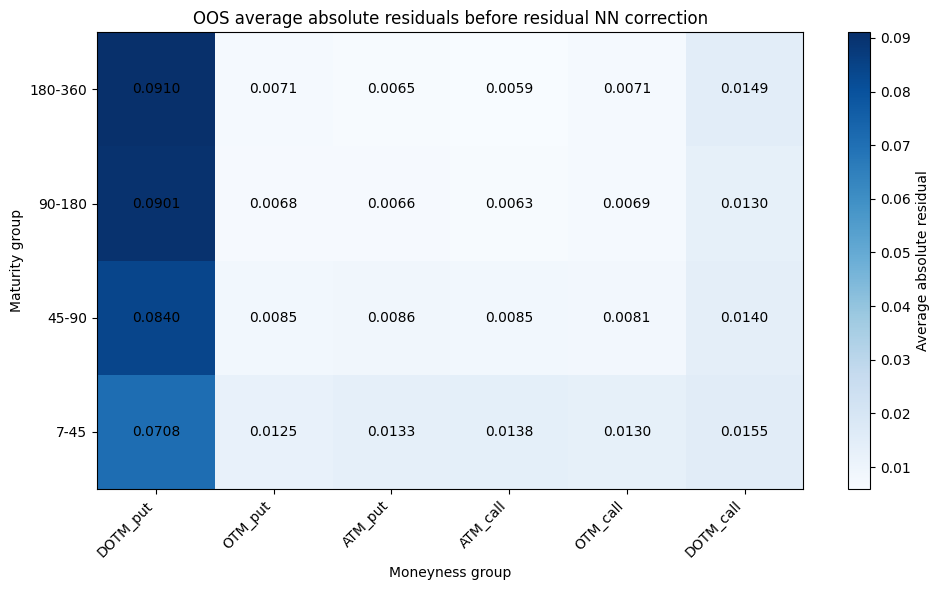

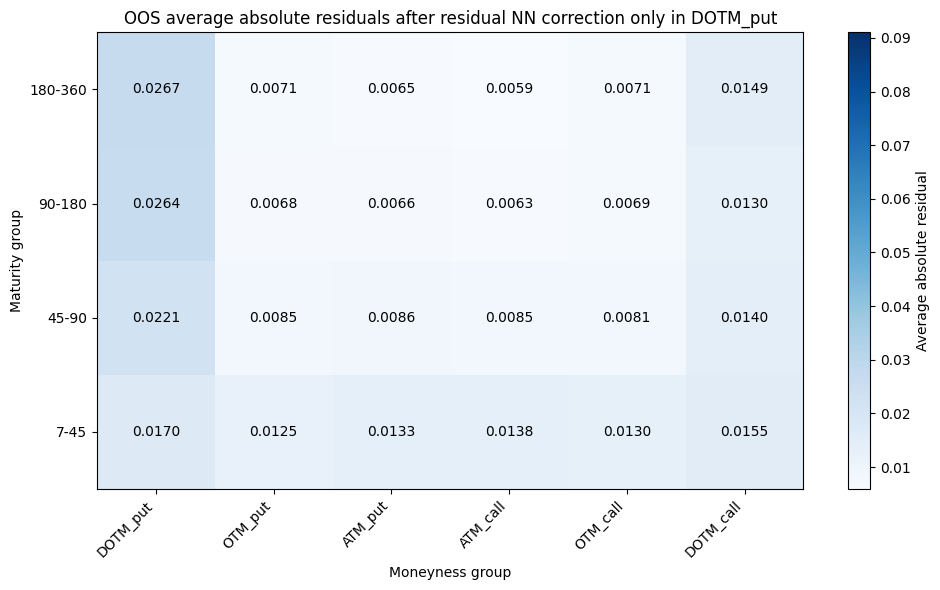

moneyness_group,DOTM_put,OTM_put,ATM_put,ATM_call,OTM_call,DOTM_call
maturity_group,,,,,,
7-45,0.017008,0.012543,0.013293,0.013759,0.012961,0.015509
45-90,0.022059,0.008483,0.008614,0.008543,0.008093,0.014022
90-180,0.026437,0.006775,0.006619,0.006349,0.006919,0.012976
180-360,0.026724,0.007126,0.006497,0.005897,0.007067,0.014859


In [90]:
# ============================================================
# Heatmaps
# ============================================================

def make_oos_nn_heatmap(
    data_heatmap,
    value_col,
    title,
    ax=None,
    show=True,
    vmin=None,
    vmax=None
):

    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    data_heatmap = data_heatmap.copy()

    data_heatmap["maturity_group"] = pd.Categorical(
        data_heatmap["maturity_group"],
        categories=maturity_order,
        ordered=True
    )

    data_heatmap["moneyness_group"] = pd.Categorical(
        data_heatmap["moneyness_group"],
        categories=moneyness_order,
        ordered=True
    )

    heatmap_table = data_heatmap.pivot_table(
        values=value_col,
        index="maturity_group",
        columns="moneyness_group",
        aggfunc="mean",
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    im = ax.imshow(
        heatmap_table,
        aspect="auto",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax
    )

    for i in range(heatmap_table.shape[0]):

        for j in range(heatmap_table.shape[1]):

            value = heatmap_table.iloc[i, j]

            if pd.notna(value):
                label = f"{value:.4f}"
            else:
                label = ""

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center"
            )

    ax.invert_yaxis()

    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")

    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)

    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Average absolute residual")

    if show:
        fig.tight_layout()
        plt.show()

    return heatmap_table


heatmap_oos_prior = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_prior",
    title="OOS average absolute residuals before residual NN correction"
)

vmin_common = heatmap_oos_prior.min().min()
vmax_common = heatmap_oos_prior.max().max()

heatmap_oos_nn_dotm_only = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_nn",
    title="OOS average absolute residuals after residual NN correction only in DOTM_put",
    vmin=vmin_common,
    vmax=vmax_common
)

heatmap_oos_nn_dotm_only

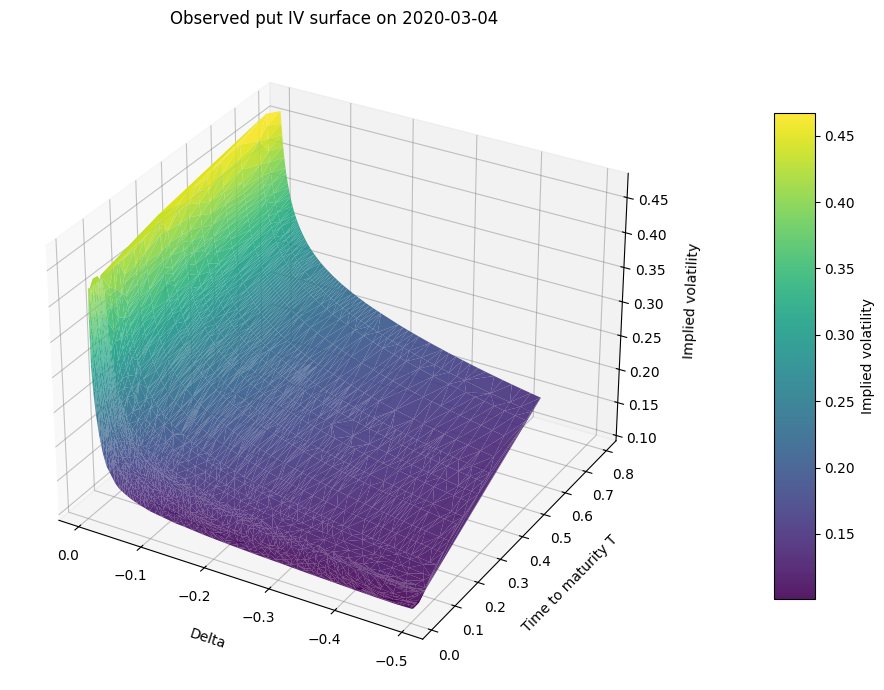

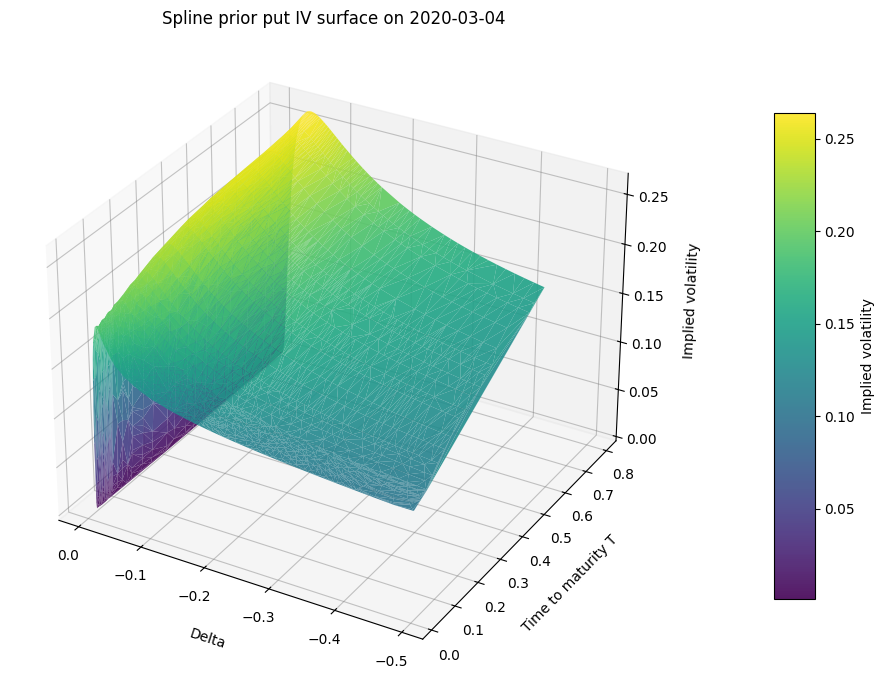

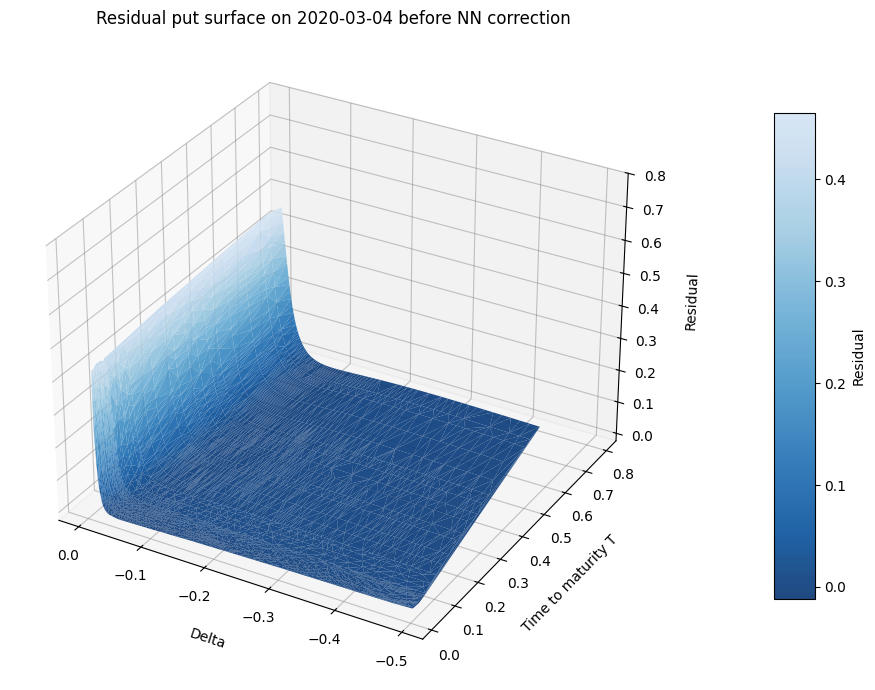

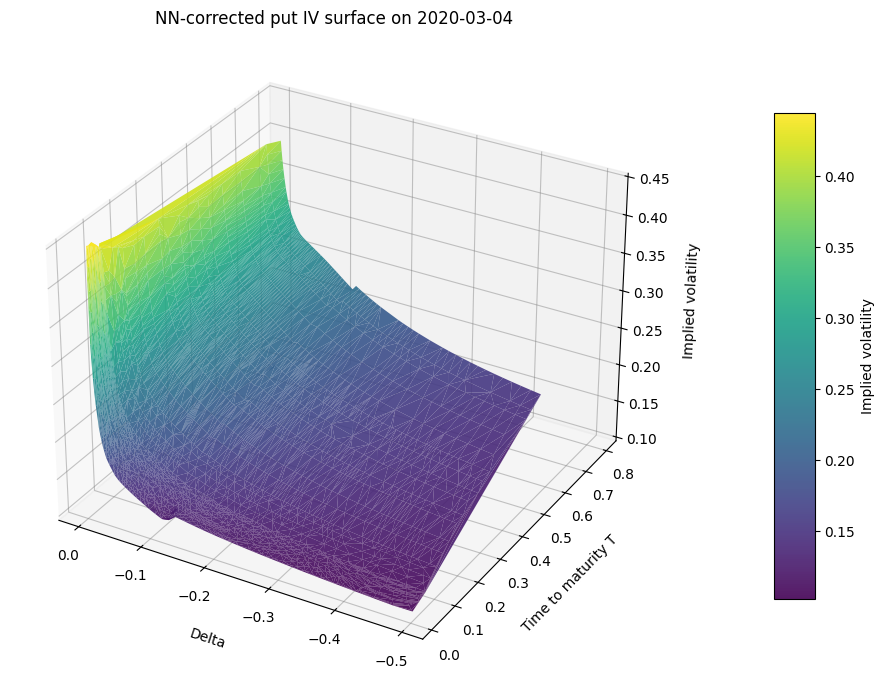

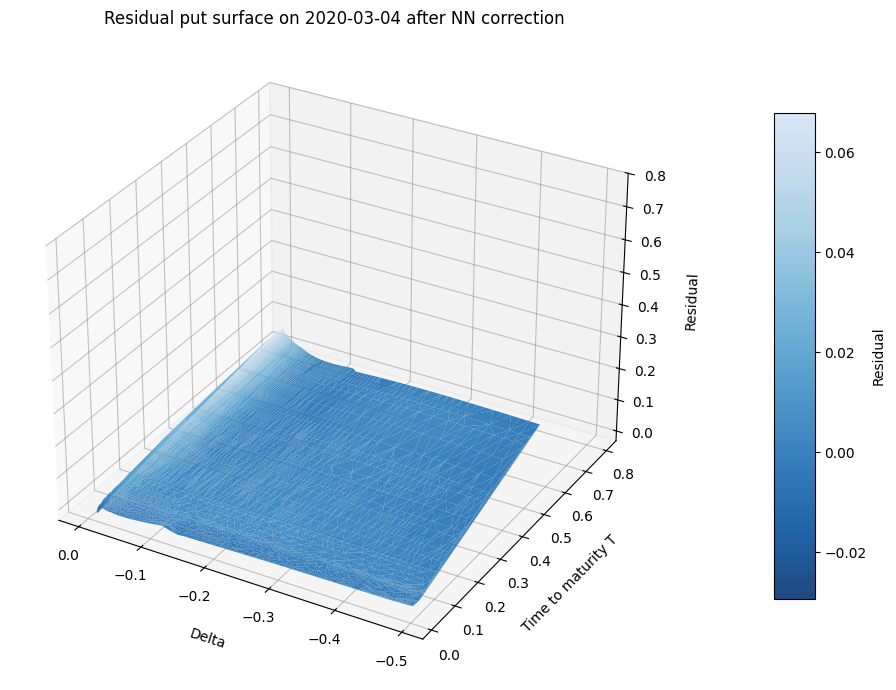

In [93]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

plot_date = pd.Timestamp("2023-07-05").date()

surface_date = x_test_nn[
    pd.to_datetime(x_test_nn["quote_date"]).dt.date.eq(plot_date)
].copy()

surface_date = surface_date[
    surface_date["moneyness_group"].isin(["DOTM_put", "OTM_put", "ATM_put"])
].copy()

surface_date["residual_prior"] = (
    surface_date["iv_fun"] - surface_date["iv_prior"]
)

surface_date["residual_nn_corrected"] = (
    surface_date["iv_fun"] - surface_date["iv_nn"]
)

blues_no_white = LinearSegmentedColormap.from_list(
    "blues_no_white",
    cm.Blues_r(np.linspace(0.02, 0.82, 256))
)


def plot_trisurf_surface(
    data,
    value_col,
    title,
    zlabel,
    zmin=None,
    zmax=None,
    cmap="viridis"
):
    plot_data = (
        data[["delta_fun", "T", value_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    x = plot_data["delta_fun"].to_numpy(dtype=float)
    y = plot_data["T"].to_numpy(dtype=float)
    z = plot_data[value_col].to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_trisurf(
        x,
        y,
        z,
        cmap=cmap,
        edgecolor="none",
        antialiased=True,
        alpha=0.9
    )

    ax.set_xlabel("Delta", labelpad=10)
    ax.set_ylabel("Time to maturity T", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()
    ax.set_title(title)

    #ax.view_init(elev=20, azim=-25)

    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

    if zmin is not None or zmax is not None:
        ax.set_zlim(bottom=zmin, top=zmax)

    cbar = fig.colorbar(
        surf,
        ax=ax,
        shrink=0.75,
        aspect=12,
        pad=0.12
    )
    cbar.set_label(zlabel)

    plt.tight_layout()
    plt.show()


plot_trisurf_surface(
    surface_date,
    "iv_fun",
    "Observed put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "iv_prior",
    "Spline prior put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_prior",
    "Residual put surface on 2020-03-04 before NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)

plot_trisurf_surface(
    surface_date,
    "iv_nn",
    "NN-corrected put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_nn_corrected",
    "Residual put surface on 2020-03-04 after NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)

In [4]:
import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import torch.nn.functional as F

# ============================================================
# Load spline results
# ============================================================

with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)


# ============================================================
# Extract spline objects
# ============================================================

at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]

x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]
data_spline_full = res_spline["data_spline_full"]


# ============================================================
# Functions needed to reconstruct spline predictions
# ============================================================

def prepare_groups_spline(x):

    dates = np.sort(x["quote_date"].unique())

    y_groups = []
    Z_groups = []

    for date in dates:

        group = x[x["quote_date"] == date]

        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    return dates, y_groups, Z_groups


def predict_iv(Z_groups, at_pred):

    log_iv_pred = []

    for t in range(len(Z_groups)):

        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    return log_iv_pred, iv_pred


# ============================================================
# Reconstruct training and testing dates from spline model
# ============================================================

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(
    x_train_spline
)

dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(
    x_test_spline
)

n_train_dates_spline = len(dates_train_spline)


# ============================================================
# Use full non-bucketed data, split by same train/test dates
# ============================================================

x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

x_test_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_test_spline)
].copy()

x_train_spline_full_nn["quote_date"] = pd.Categorical(
    x_train_spline_full_nn["quote_date"],
    categories=dates_train_spline,
    ordered=True
)

x_test_spline_full_nn["quote_date"] = pd.Categorical(
    x_test_spline_full_nn["quote_date"],
    categories=dates_test_spline,
    ordered=True
)

x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)


# ============================================================
# Compute spline prior on full non-bucketed training data
# ============================================================

dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn
)

log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)]
)


# ============================================================
# Compute spline prior on full non-bucketed testing data
# ============================================================

dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline(
    x_test_spline_full_nn
)

log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
    Z_groups_test_full_spline_nn,
    at_pred_spline[
        :,
        n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)
    ]
)


# ============================================================
# Create NN training dataframe from full non-bucketed training data
# ============================================================

x_train_nn = x_train_spline_full_nn.copy()

x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

x_train_nn["residual_target"] = (
    x_train_nn["iv_fun"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_prior"] = np.abs(
    x_train_nn["residual_target"]
)


# ============================================================
# Clean training data
# ============================================================

x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)

x_train_nn = x_train_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "residual_target",
        "moneyness_group",
        "maturity_group"
    ]
).copy()


# ============================================================
# Train only on DOTM_put
# ============================================================

x_train_nn = x_train_nn[
    x_train_nn["moneyness_group"].eq("DOTM_put")
].copy()


# ============================================================
# Features
# ============================================================

feature_cols = ["M", "T", "iv_prior"]

print("Number of full non-bucketed DOTM_put training observations:", len(x_train_nn))
print("Average spline residual in DOTM_put:", x_train_nn["residual_target"].mean())
print("Spline prior MAE on full non-bucketed DOTM_put training data:", x_train_nn["abs_error_prior"].mean())


# ============================================================
# Define neural network that predicts unrestricted positive
# total-variance multiplier
# ============================================================

class ResidualNN(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(n_features, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh()
        )

        self.output = nn.Linear(80, 1)

        self.initialize_weights()

    def initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Linear):

                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                std = (fan_in + fan_out) ** (-0.5)

                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Starts from no correction: exp(0) = 1
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x):

        x = self.hidden(x)

        log_omega_multiplier = self.output(x)

        omega_multiplier = torch.exp(log_omega_multiplier)

        return omega_multiplier


# ============================================================
# Prepare NN training data
# ============================================================

X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
iv_prior = x_train_nn[["iv_prior"]].to_numpy(dtype=float)
T = x_train_nn[["T"]].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
T_tensor = torch.tensor(T, dtype=torch.float32)

dataset = TensorDataset(
    X_tensor,
    y_tensor,
    iv_prior_tensor,
    T_tensor
)

loader = DataLoader(
    dataset,
    batch_size=16384,
    shuffle=True
)


# ============================================================
# Train neural network using RMSE + MAPE on final IV
# ============================================================

model = ResidualNN(n_features=len(feature_cols))

initial_lr = 0.001
current_lr = initial_lr

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6
)

max_epochs = 400
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

loss_history = []

for epoch in range(max_epochs):

    total_loss = 0.0

    for X_batch, y_batch, iv_prior_batch, T_batch in loader:

        optimizer.zero_grad()

        omega_multiplier = model(X_batch)

        omega_prior = iv_prior_batch ** 2 * T_batch
        omega_pred = omega_multiplier * omega_prior

        iv_pred = torch.sqrt(
            torch.clamp(
                omega_pred / torch.clamp(T_batch, min=1e-8),
                min=1e-12
            )
        )

        rmse = torch.sqrt(
            torch.mean((y_batch - iv_pred) ** 2)
        )

        mape = torch.mean(
            torch.abs(y_batch - iv_pred)
            / torch.clamp(y_batch, min=1e-8)
        )

        loss = rmse + mape

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    if epoch > 0 and epoch % lr_check_window == 0:

        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:

            current_lr = current_lr / 2

            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    if epoch > 0 and epoch % stop_check_window == 0:

        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break


# ============================================================
# Store fitted correction on DOTM_put training data
# ============================================================

model.eval()

with torch.no_grad():

    omega_multiplier_train = model(X_tensor).numpy().flatten()

x_train_nn["omega_multiplier_nn"] = omega_multiplier_train

omega_prior_train = (
    x_train_nn["iv_prior"].to_numpy(dtype=float) ** 2
    * x_train_nn["T"].to_numpy(dtype=float)
)

omega_nn_train = (
    x_train_nn["omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_train
)

x_train_nn["iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_train
        / np.maximum(x_train_nn["T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_train_nn["iv_nn"] = x_train_nn["iv_nn"].clip(lower=1e-6)

x_train_nn["residual_nn"] = (
    x_train_nn["iv_nn"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_nn"] = np.abs(
    x_train_nn["iv_fun"] - x_train_nn["iv_nn"]
)

print("NN corrected MAE on full non-bucketed DOTM_put training data:", x_train_nn["abs_error_nn"].mean())
print("Average omega multiplier on DOTM_put training data:", x_train_nn["omega_multiplier_nn"].mean())
print("Minimum omega multiplier on DOTM_put training data:", x_train_nn["omega_multiplier_nn"].min())
print("Maximum omega multiplier on DOTM_put training data:", x_train_nn["omega_multiplier_nn"].max())


# ============================================================
# Evaluate on full non-bucketed testing data
# Correction is applied only to DOTM_put
# All other regions keep the spline prediction exactly
# ============================================================

x_test_nn = x_test_spline_full_nn.copy()

x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn

x_test_nn = x_test_nn.replace([np.inf, -np.inf], np.nan)

x_test_nn = x_test_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "moneyness_group",
        "maturity_group"
    ]
).copy()

# Default: no correction outside DOTM_put
x_test_nn["residual_nn"] = 0.0
x_test_nn["omega_multiplier_nn"] = 1.0
x_test_nn["iv_nn"] = x_test_nn["iv_prior"]

dotm_put_mask = x_test_nn["moneyness_group"].eq("DOTM_put")

X_test_dotm = x_test_nn.loc[
    dotm_put_mask,
    feature_cols
].to_numpy(dtype=float)

X_test_dotm_scaled = scaler.transform(X_test_dotm)
X_test_dotm_tensor = torch.tensor(X_test_dotm_scaled, dtype=torch.float32)

model.eval()

with torch.no_grad():

    x_test_nn.loc[dotm_put_mask, "omega_multiplier_nn"] = (
        model(X_test_dotm_tensor)
        .numpy()
        .flatten()
    )

omega_prior_test = (
    x_test_nn.loc[dotm_put_mask, "iv_prior"].to_numpy(dtype=float) ** 2
    * x_test_nn.loc[dotm_put_mask, "T"].to_numpy(dtype=float)
)

omega_nn_test = (
    x_test_nn.loc[dotm_put_mask, "omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_test
)

x_test_nn.loc[dotm_put_mask, "iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_test
        / np.maximum(x_test_nn.loc[dotm_put_mask, "T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_test_nn["iv_nn"] = x_test_nn["iv_nn"].clip(lower=1e-6)

x_test_nn["residual_nn"] = (
    x_test_nn["iv_nn"] - x_test_nn["iv_prior"]
)

x_test_nn.loc[~dotm_put_mask, "residual_nn"] = 0.0

x_test_nn["abs_error_prior"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_prior"]
)

x_test_nn["abs_error_nn"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_nn"]
)

print("Spline prior MAE on full non-bucketed testing data:", x_test_nn["abs_error_prior"].mean())
print("NN total-variance multiplicative-corrected MAE on full non-bucketed testing data, DOTM_put only:", x_test_nn["abs_error_nn"].mean())

print("Average predicted residual by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["residual_nn"].mean())

print("Average predicted omega multiplier by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["omega_multiplier_nn"].mean())

print("OOS MAE by moneyness group:")
print(
    x_test_nn
    .groupby("moneyness_group")[["abs_error_prior", "abs_error_nn"]]
    .mean()
)

Number of full non-bucketed DOTM_put training observations: 829095
Average spline residual in DOTM_put: 0.05194607145850939
Spline prior MAE on full non-bucketed DOTM_put training data: 0.05949881055908489
0 0.22969534876299838 lr: 0.001
50 0.0768808069474557 lr: 0.001
100 0.0763939908322166 lr: 0.001
150 0.07585343207214393 lr: 0.001
200 0.0758690103596332 lr: 0.001
250 0.0757368746049264 lr: 0.001
300 0.07573668527252533 lr: 0.001
Reduced learning rate to 0.0005 at epoch 300
350 0.07561980363200693 lr: 0.0005
NN corrected MAE on full non-bucketed DOTM_put training data: 0.01307910225521449
Average omega multiplier on DOTM_put training data: 27.74334
Minimum omega multiplier on DOTM_put training data: 0.12633781
Maximum omega multiplier on DOTM_put training data: 1500.0002
Spline prior MAE on full non-bucketed testing data: 0.03289584076518888
NN total-variance multiplicative-corrected MAE on full non-bucketed testing data, DOTM_put only: 0.015385914779594678
Average predicted residua

In [ ]:
import pandas as pd
import numpy as np
import pickle

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import torch.nn.functional as F


# ============================================================
# Load spline results
# ============================================================

with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)


# ============================================================
# Extract spline objects
# ============================================================

at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]

x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]
data_spline_full = res_spline["data_spline_full"]


# ============================================================
# Functions needed to reconstruct spline predictions
# ============================================================

def prepare_groups_spline(x):

    dates = np.sort(x["quote_date"].unique())

    y_groups = []
    Z_groups = []

    for date in dates:

        group = x[x["quote_date"] == date]

        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    return dates, y_groups, Z_groups


def predict_iv(Z_groups, at_pred):

    log_iv_pred = []

    for t in range(len(Z_groups)):

        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    return log_iv_pred, iv_pred


# ============================================================
# Reconstruct training and testing dates from spline model
# ============================================================

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(
    x_train_spline
)

dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(
    x_test_spline
)

n_train_dates_spline = len(dates_train_spline)


# ============================================================
# Use full non-bucketed data, split by same train/test dates
# ============================================================

x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

x_test_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_test_spline)
].copy()

x_train_spline_full_nn["quote_date"] = pd.Categorical(
    x_train_spline_full_nn["quote_date"],
    categories=dates_train_spline,
    ordered=True
)

x_test_spline_full_nn["quote_date"] = pd.Categorical(
    x_test_spline_full_nn["quote_date"],
    categories=dates_test_spline,
    ordered=True
)

x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)


# ============================================================
# Compute spline prior on full non-bucketed training data
# ============================================================

dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn
)

log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)]
)


# ============================================================
# Compute spline prior on full non-bucketed testing data
# ============================================================

dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline(
    x_test_spline_full_nn
)

log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
    Z_groups_test_full_spline_nn,
    at_pred_spline[
        :,
        n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)
    ]
)


# ============================================================
# Create NN training dataframe from full non-bucketed training data
# ============================================================

x_train_nn = x_train_spline_full_nn.copy()

x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

iv_prior_floor = 0.03
x_train_nn["iv_prior_safe"] = x_train_nn["iv_prior"].clip(lower=iv_prior_floor)

x_train_nn["residual_target"] = (
    x_train_nn["iv_fun"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_prior"] = np.abs(
    x_train_nn["residual_target"]
)


# ============================================================
# Clean training data
# ============================================================

x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)

x_train_nn = x_train_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "iv_prior_safe",
        "residual_target",
        "moneyness_group",
        "maturity_group"
    ]
).copy()


# ============================================================
# Train on DOTM_put and OTM_put
# ============================================================

x_train_nn = x_train_nn[
    x_train_nn["moneyness_group"].isin(["DOTM_put", "OTM_put"])
].copy()


# ============================================================
# Features
# ============================================================

feature_cols = ["M", "T", "iv_prior_safe"]

print("Number of full non-bucketed DOTM_put + OTM_put training observations:", len(x_train_nn))
print("Average spline residual in DOTM_put + OTM_put:", x_train_nn["residual_target"].mean())
print("Spline prior MAE on full non-bucketed DOTM_put + OTM_put training data:", x_train_nn["abs_error_prior"].mean())


# ============================================================
# Define neural network that predicts unrestricted positive
# total-variance multiplier
# ============================================================

class ResidualNN(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(n_features, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh(),

            nn.Linear(80, 80),
            nn.Tanh()
        )

        self.output = nn.Linear(80, 1)

        self.initialize_weights()

    def initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Linear):

                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                std = (fan_in + fan_out) ** (-0.5)

                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Starts from no correction: exp(0) = 1
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x):

        x = self.hidden(x)

        log_omega_multiplier = self.output(x)

        omega_multiplier = torch.exp(log_omega_multiplier)

        return omega_multiplier


# ============================================================
# Prepare NN training data
# ============================================================

X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
iv_prior = x_train_nn[["iv_prior_safe"]].to_numpy(dtype=float)
T = x_train_nn[["T"]].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
T_tensor = torch.tensor(T, dtype=torch.float32)

dataset = TensorDataset(
    X_tensor,
    y_tensor,
    iv_prior_tensor,
    T_tensor
)

loader = DataLoader(
    dataset,
    batch_size=16384,
    shuffle=True
)


# ============================================================
# Train neural network using RMSE + MAPE on final IV
# ============================================================

model = ResidualNN(n_features=len(feature_cols))

initial_lr = 0.001
current_lr = initial_lr

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6
)

max_epochs = 400
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

loss_history = []

for epoch in range(max_epochs):

    total_loss = 0.0

    for X_batch, y_batch, iv_prior_batch, T_batch in loader:

        optimizer.zero_grad()

        omega_multiplier = model(X_batch)

        omega_prior = iv_prior_batch ** 2 * T_batch
        omega_pred = omega_multiplier * omega_prior

        iv_pred = torch.sqrt(
            torch.clamp(
                omega_pred / torch.clamp(T_batch, min=1e-8),
                min=1e-12
            )
        )

        rmse = torch.sqrt(
            torch.mean((y_batch - iv_pred) ** 2)
        )

        mape = torch.mean(
            torch.abs(y_batch - iv_pred)
            / torch.clamp(y_batch, min=1e-8)
        )

        loss = rmse + mape

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    if epoch > 0 and epoch % lr_check_window == 0:

        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:

            current_lr = current_lr / 2

            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    if epoch > 0 and epoch % stop_check_window == 0:

        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break


# ============================================================
# Store fitted correction on DOTM_put + OTM_put training data
# ============================================================

model.eval()

with torch.no_grad():

    omega_multiplier_train = model(X_tensor).numpy().flatten()

x_train_nn["omega_multiplier_nn"] = omega_multiplier_train

omega_prior_train = (
    x_train_nn["iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_train_nn["T"].to_numpy(dtype=float)
)

omega_nn_train = (
    x_train_nn["omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_train
)

x_train_nn["iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_train
        / np.maximum(x_train_nn["T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_train_nn["iv_nn"] = x_train_nn["iv_nn"].clip(lower=1e-6)

x_train_nn["residual_nn"] = (
    x_train_nn["iv_nn"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_nn"] = np.abs(
    x_train_nn["iv_fun"] - x_train_nn["iv_nn"]
)

print("NN corrected MAE on full non-bucketed DOTM_put + OTM_put training data:", x_train_nn["abs_error_nn"].mean())
print("Average omega multiplier on DOTM_put + OTM_put training data:", x_train_nn["omega_multiplier_nn"].mean())
print("Minimum omega multiplier on DOTM_put + OTM_put training data:", x_train_nn["omega_multiplier_nn"].min())
print("Maximum omega multiplier on DOTM_put + OTM_put training data:", x_train_nn["omega_multiplier_nn"].max())


# ============================================================
# Evaluate on full non-bucketed testing data
# Correction is applied only to DOTM_put and OTM_put
# All other regions keep the spline prediction exactly
# ============================================================

x_test_nn = x_test_spline_full_nn.copy()

x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn

x_test_nn["iv_prior_safe"] = x_test_nn["iv_prior"].clip(lower=iv_prior_floor)

x_test_nn = x_test_nn.replace([np.inf, -np.inf], np.nan)

x_test_nn = x_test_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "iv_prior_safe",
        "moneyness_group",
        "maturity_group"
    ]
).copy()

# Default: no correction outside DOTM_put and OTM_put
x_test_nn["residual_nn"] = 0.0
x_test_nn["omega_multiplier_nn"] = 1.0
x_test_nn["iv_nn"] = x_test_nn["iv_prior"]

dotm_put_mask = x_test_nn["moneyness_group"].isin(["DOTM_put", "OTM_put"])

X_test_dotm = x_test_nn.loc[
    dotm_put_mask,
    feature_cols
].to_numpy(dtype=float)

X_test_dotm_scaled = scaler.transform(X_test_dotm)
X_test_dotm_tensor = torch.tensor(X_test_dotm_scaled, dtype=torch.float32)

model.eval()

with torch.no_grad():

    x_test_nn.loc[dotm_put_mask, "omega_multiplier_nn"] = (
        model(X_test_dotm_tensor)
        .numpy()
        .flatten()
    )

omega_prior_test = (
    x_test_nn.loc[dotm_put_mask, "iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_test_nn.loc[dotm_put_mask, "T"].to_numpy(dtype=float)
)

omega_nn_test = (
    x_test_nn.loc[dotm_put_mask, "omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_test
)

x_test_nn.loc[dotm_put_mask, "iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_test
        / np.maximum(x_test_nn.loc[dotm_put_mask, "T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_test_nn["iv_nn"] = x_test_nn["iv_nn"].clip(lower=1e-6)

x_test_nn["residual_nn"] = (
    x_test_nn["iv_nn"] - x_test_nn["iv_prior"]
)

x_test_nn.loc[~dotm_put_mask, "residual_nn"] = 0.0

x_test_nn["abs_error_prior"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_prior"]
)

x_test_nn["abs_error_nn"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_nn"]
)

print("Spline prior MAE on full non-bucketed testing data:", x_test_nn["abs_error_prior"].mean())
print("NN total-variance multiplicative-corrected MAE on full non-bucketed testing data, DOTM_put + OTM_put only:", x_test_nn["abs_error_nn"].mean())

print("Average predicted residual by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["residual_nn"].mean())

print("Average predicted omega multiplier by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["omega_multiplier_nn"].mean())

print("OOS MAE by moneyness group:")
print(
    x_test_nn
    .groupby("moneyness_group")[["abs_error_prior", "abs_error_nn"]]
    .mean()
)

Number of full non-bucketed DOTM_put + OTM_put training observations: 1286337
Average spline residual in DOTM_put + OTM_put: 0.03356014634265737
Spline prior MAE on full non-bucketed DOTM_put + OTM_put training data: 0.04106674562722026
0 0.1733104654505283 lr: 0.001
50 0.053749813875065576 lr: 0.001
100 0.05353378773301463 lr: 0.001
150 0.05341511861055712 lr: 0.001


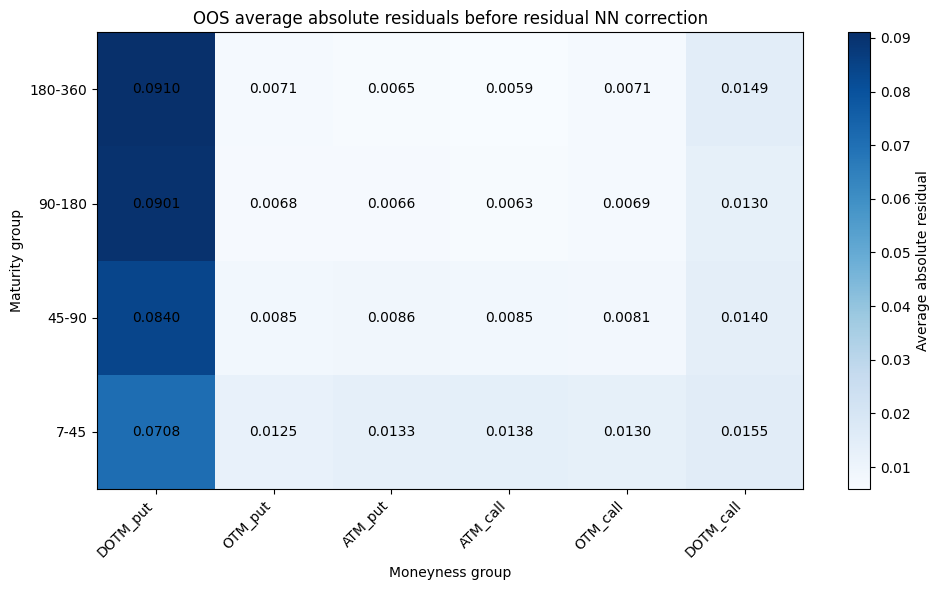

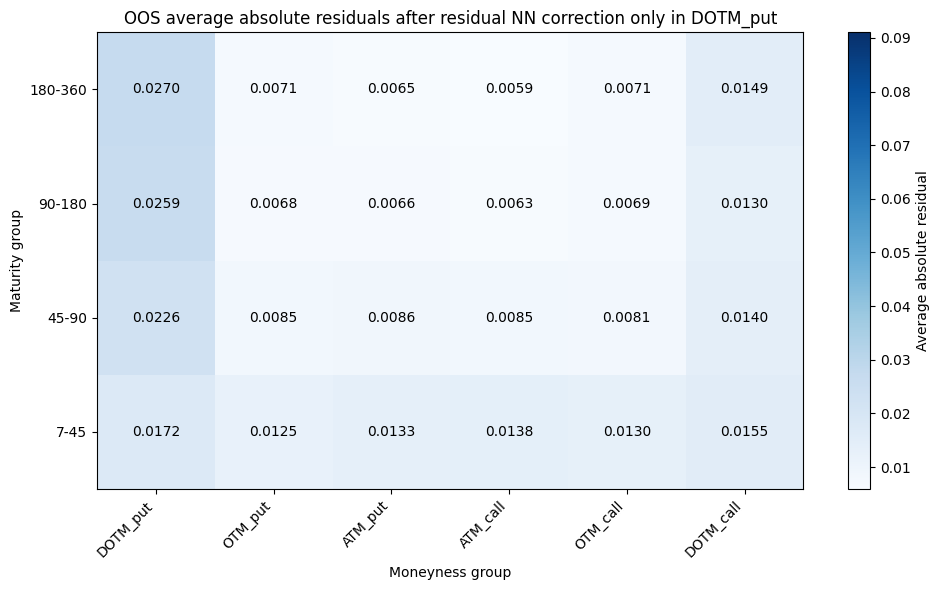

moneyness_group,DOTM_put,OTM_put,ATM_put,ATM_call,OTM_call,DOTM_call
maturity_group,,,,,,
7-45,0.017219,0.012543,0.013293,0.013759,0.012961,0.015509
45-90,0.022623,0.008483,0.008614,0.008543,0.008093,0.014022
90-180,0.025856,0.006775,0.006619,0.006349,0.006919,0.012976
180-360,0.026985,0.007126,0.006497,0.005897,0.007067,0.014859


In [8]:

def make_oos_nn_heatmap(
    data_heatmap,
    value_col,
    title,
    ax=None,
    show=True,
    vmin=None,
    vmax=None
):

    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    data_heatmap = data_heatmap.copy()

    data_heatmap["maturity_group"] = pd.Categorical(
        data_heatmap["maturity_group"],
        categories=maturity_order,
        ordered=True
    )

    data_heatmap["moneyness_group"] = pd.Categorical(
        data_heatmap["moneyness_group"],
        categories=moneyness_order,
        ordered=True
    )

    heatmap_table = data_heatmap.pivot_table(
        values=value_col,
        index="maturity_group",
        columns="moneyness_group",
        aggfunc="mean",
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    im = ax.imshow(
        heatmap_table,
        aspect="auto",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax
    )

    for i in range(heatmap_table.shape[0]):

        for j in range(heatmap_table.shape[1]):

            value = heatmap_table.iloc[i, j]

            if pd.notna(value):
                label = f"{value:.4f}"
            else:
                label = ""

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center"
            )

    ax.invert_yaxis()

    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")

    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)

    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Average absolute residual")

    if show:
        fig.tight_layout()
        plt.show()

    return heatmap_table


heatmap_oos_prior = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_prior",
    title="OOS average absolute residuals before residual NN correction"
)

vmin_common = heatmap_oos_prior.min().min()
vmax_common = heatmap_oos_prior.max().max()

heatmap_oos_nn_dotm_only = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_nn",
    title="OOS average absolute residuals after residual NN correction only in DOTM_put",
    vmin=vmin_common,
    vmax=vmax_common
)

heatmap_oos_nn_dotm_only

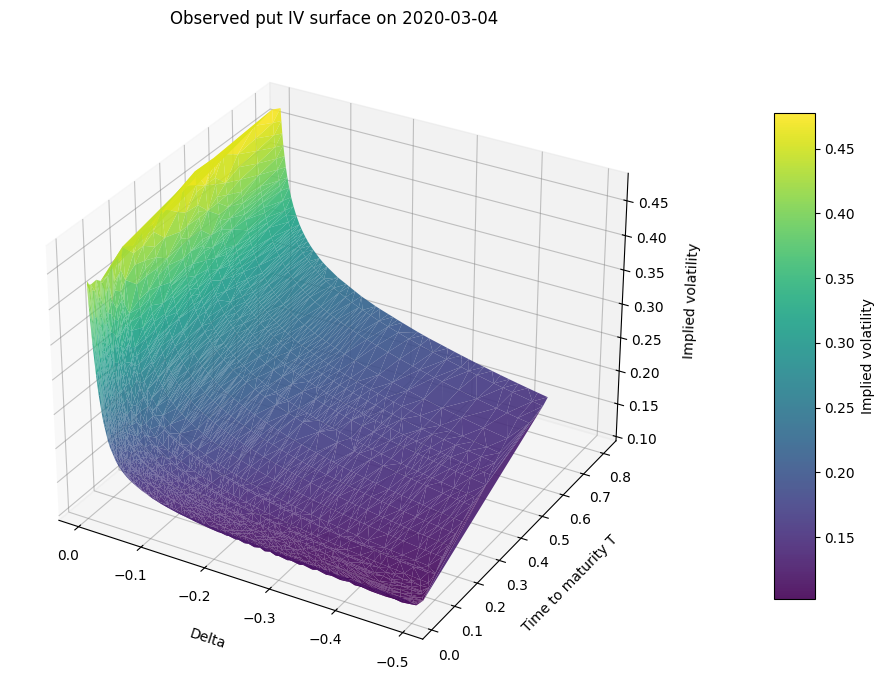

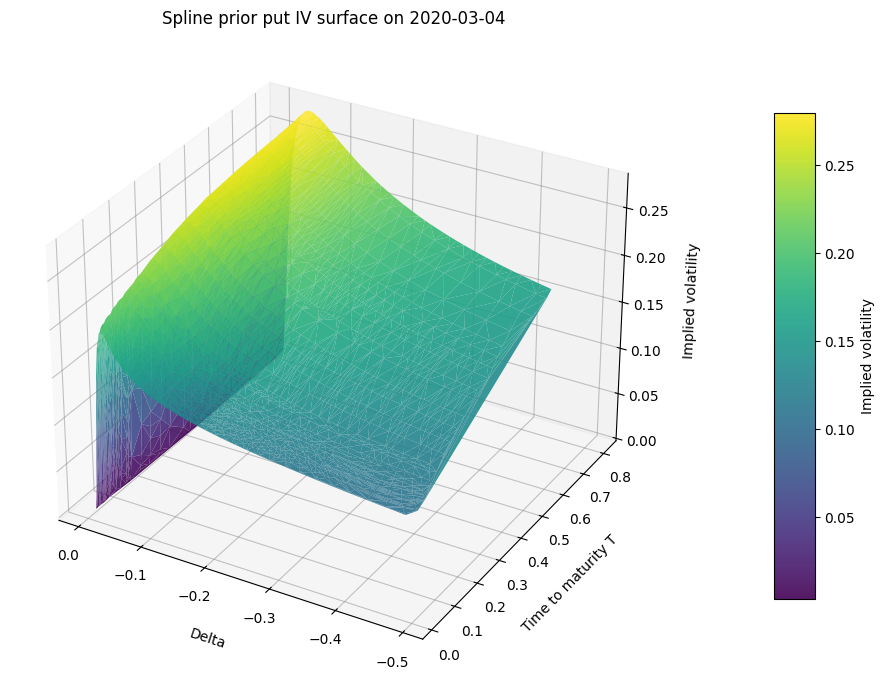

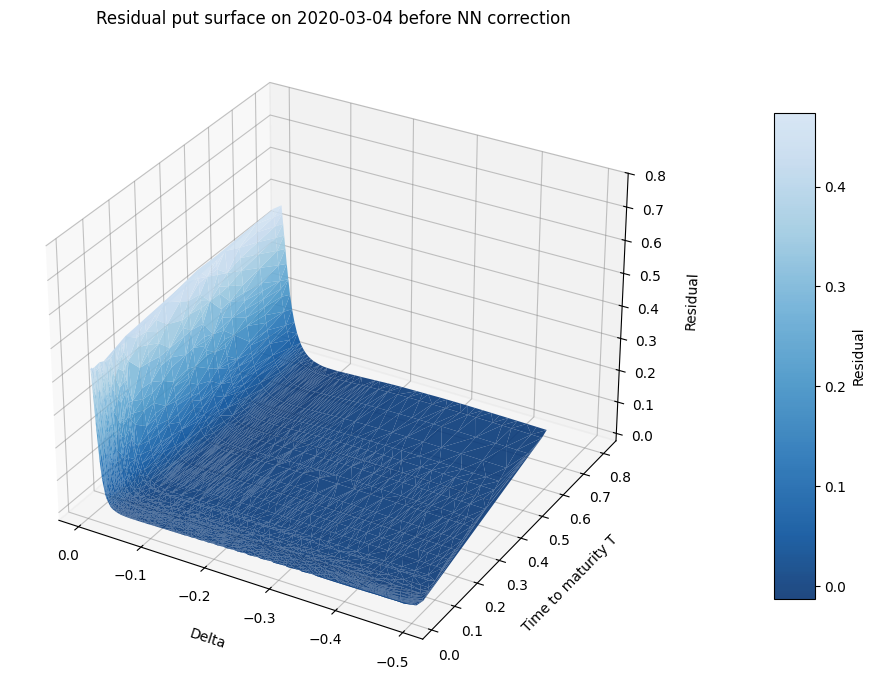

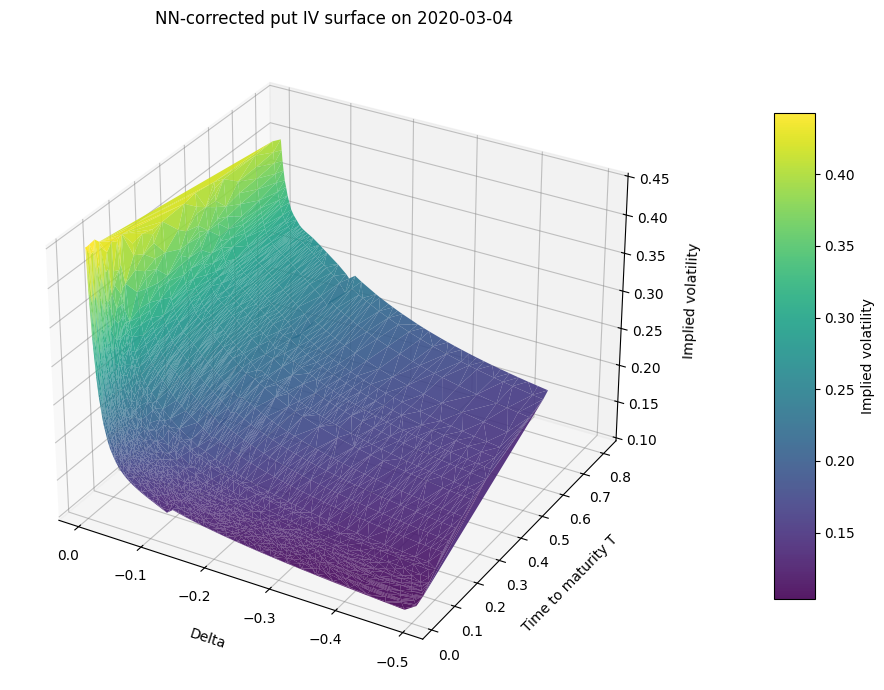

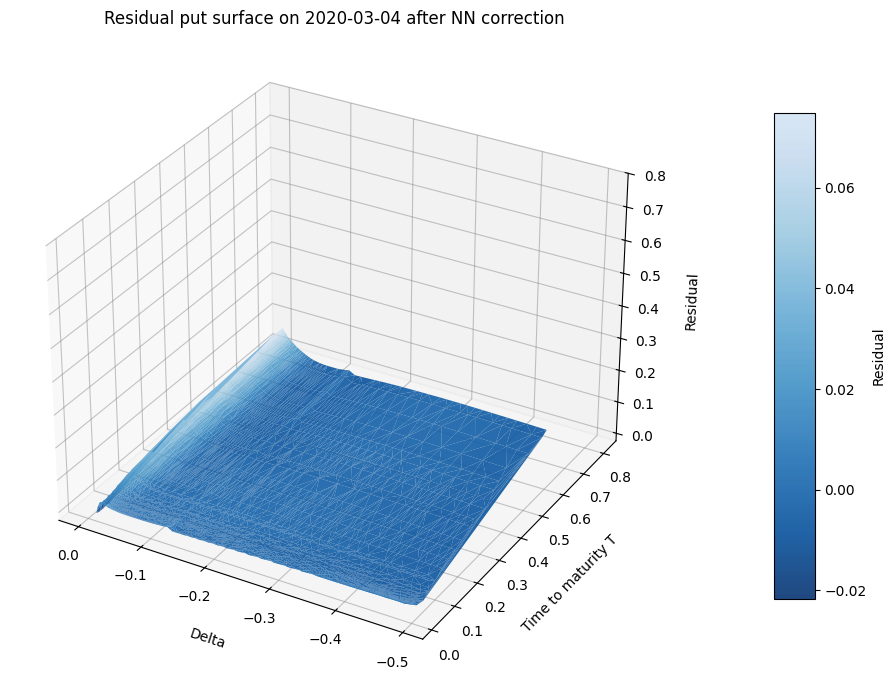

In [24]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

plot_date = pd.Timestamp("2023-06-08").date()

surface_date = x_test_nn[
    pd.to_datetime(x_test_nn["quote_date"]).dt.date.eq(plot_date)
].copy()

surface_date = surface_date[
    surface_date["moneyness_group"].isin(["DOTM_put", "OTM_put", "ATM_put"])
].copy()

surface_date["residual_prior"] = (
    surface_date["iv_fun"] - surface_date["iv_prior"]
)

surface_date["residual_nn_corrected"] = (
    surface_date["iv_fun"] - surface_date["iv_nn"]
)

blues_no_white = LinearSegmentedColormap.from_list(
    "blues_no_white",
    cm.Blues_r(np.linspace(0.02, 0.82, 256))
)


def plot_trisurf_surface(
    data,
    value_col,
    title,
    zlabel,
    zmin=None,
    zmax=None,
    cmap="viridis"
):
    plot_data = (
        data[["delta_fun", "T", value_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    x = plot_data["delta_fun"].to_numpy(dtype=float)
    y = plot_data["T"].to_numpy(dtype=float)
    z = plot_data[value_col].to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_trisurf(
        x,
        y,
        z,
        cmap=cmap,
        edgecolor="none",
        antialiased=True,
        alpha=0.9
    )

    ax.set_xlabel("Delta", labelpad=10)
    ax.set_ylabel("Time to maturity T", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()
    ax.set_title(title)

    #ax.view_init(elev=20, azim=-25)

    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

    if zmin is not None or zmax is not None:
        ax.set_zlim(bottom=zmin, top=zmax)

    cbar = fig.colorbar(
        surf,
        ax=ax,
        shrink=0.75,
        aspect=12,
        pad=0.12
    )
    cbar.set_label(zlabel)

    plt.tight_layout()
    plt.show()


plot_trisurf_surface(
    surface_date,
    "iv_fun",
    "Observed put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "iv_prior",
    "Spline prior put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_prior",
    "Residual put surface on 2020-03-04 before NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)

plot_trisurf_surface(
    surface_date,
    "iv_nn",
    "NN-corrected put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_nn_corrected",
    "Residual put surface on 2020-03-04 after NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)